# Walmart Sales (Modified version)

In [1]:
import pandas as pd
import numpy as np

In [2]:
#load the data
data = pd.read_csv('Walmart_Sales.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
data.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

In [10]:
# check duplicates
data.duplicated().sum()
#data = data.drop_duplicates()

0

In [11]:
#check missing data
data.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [12]:
#data.drop(columns=[], inplace = True)
#data.dropna(subset=[], inplace = True)

# Feature engineering

In [14]:
data['DateString']=data['Date']

In [15]:
data['Date']=pd.to_datetime(data['DateString'], dayfirst=True)

In [16]:
data['Year'] = data['Date'].dt.year

In [19]:
data['Month']=data['Date'].dt.month

In [20]:
data['Week']=data['Date'].dt.week

/var/folders/nb/pwcr6tcd1bb0ywz4_rbr0vt80000gn/T/ipykernel_16302/3702246027.py:1: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  data['Week']=data['Date'].dt.week


In [27]:
data.loc[data['Month'].isin([3,4,5]), 'Season'] = 'Spring'
data.loc[data['Month'].isin([6,7,8]), 'Season'] = 'Summer'
data.loc[data['Month'].isin([9,10,11]), 'Season']='Autumn'
data.loc[data['Month'].isin([12,1,2]),'Season']='Winter'

In [40]:
data.sort_values(by=['Store', 'Date'], inplace = True)

In [43]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString,Year,Month,Week,Season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,05-02-2010,2010,2,5,Winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12-02-2010,2010,2,6,Winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19-02-2010,2010,2,7,Winter
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26-02-2010,2010,2,8,Winter
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,05-03-2010,2010,3,9,Spring


In [45]:
#Time series features
data['Last_Week_Sale'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=1).mean()).reset_index(level=0, drop=True)
)

In [48]:
data['Last_4Week_Sale_mean'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(4).rolling(window=4).mean()).reset_index(level=0, drop=True)
)

In [49]:
data['Last_4Week_Sale_std'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(4).rolling(window=4).std()).reset_index(level=0, drop=True)
)

In [50]:
data['Last_12Week_Sale_mean'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(12).rolling(window=12).mean()).reset_index(level=0, drop=True)
)

In [51]:
data['Last_12Week_Sale_std'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(12).rolling(window=12).std()).reset_index(level=0, drop=True)
)

In [54]:
data = data.dropna(subset=['Last_12Week_Sale_std'])

In [55]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString,Year,Month,Week,Season,Last_Week_Sale,Last_4Week_Sale_mean,Last_4Week_Sale_std,Last_12Week_Sale_mean,Last_12Week_Sale_std
23,1,2010-07-16,1448938.92,0,83.15,2.623,211.100385,7.787,16-07-2010,2010,7,28,Summer,1546074.18,1.523360e+06,76594.021138,1.514695e+06,95107.965230
24,1,2010-07-23,1385065.20,0,83.36,2.608,211.235144,7.787,23-07-2010,2010,7,29,Summer,1448938.92,1.521020e+06,80362.229620,1.496479e+06,88885.083286
25,1,2010-07-30,1371986.60,0,81.84,2.640,211.369903,7.787,30-07-2010,2010,7,30,Summer,1385065.20,1.490244e+06,49908.159003,1.493312e+06,83759.904242
26,1,2010-08-06,1605491.78,0,87.16,2.627,211.504662,7.787,06-08-2010,2010,8,31,Summer,1371986.60,1.491122e+06,51151.150516,1.483503e+06,75039.274445
27,1,2010-08-13,1508237.76,0,87.00,2.692,211.639421,7.787,13-08-2010,2010,8,32,Summer,1605491.78,1.477536e+06,53982.923313,1.482664e+06,75989.148419


## EDA

In [61]:
import matplotlib.pyplot as plt

In [56]:
import seaborn as sns

In [58]:
selected_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price','CPI']

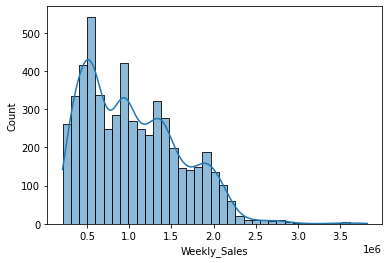

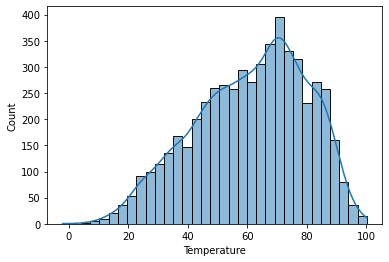

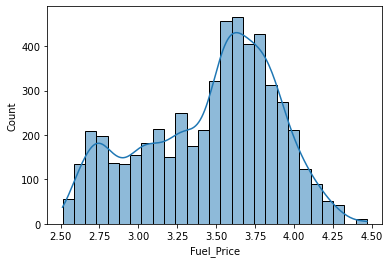

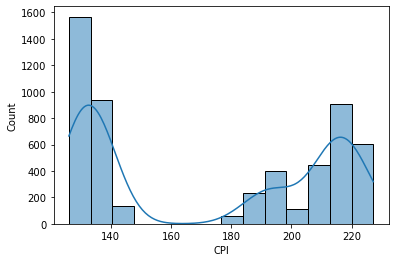

In [62]:
## Univariant
for feature in selected_columns:
    plt.figure()
    sns.histplot(data[feature], kde=True)
    plt.show()

In [64]:
data.dtypes

Store                             int64
Date                     datetime64[ns]
Weekly_Sales                    float64
Holiday_Flag                      int64
Temperature                     float64
Fuel_Price                      float64
CPI                             float64
Unemployment                    float64
DateString                       object
Year                              int64
Month                             int64
Week                              int64
Season                           object
Last_Week_Sale                  float64
Last_4Week_Sale_mean            float64
Last_4Week_Sale_std             float64
Last_12Week_Sale_mean           float64
Last_12Week_Sale_std            float64
dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

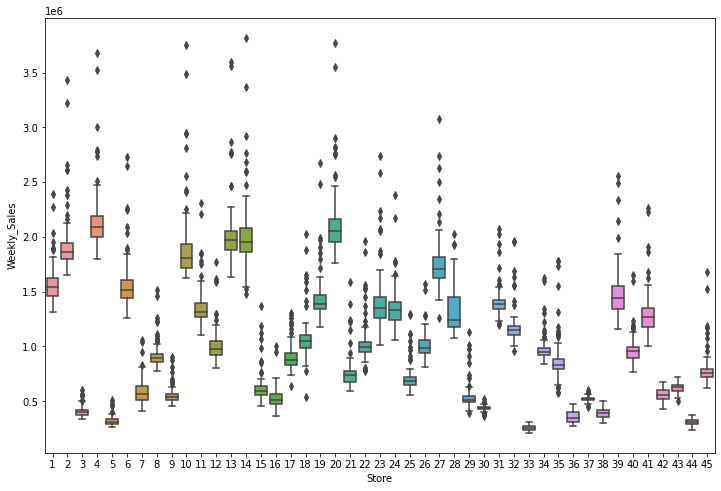

In [68]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data, x='Store',y='Weekly_Sales')
plt.show

In [69]:
data.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'DateString', 'Year', 'Month',
       'Week', 'Season', 'Last_Week_Sale', 'Last_4Week_Sale_mean',
       'Last_4Week_Sale_std', 'Last_12Week_Sale_mean', 'Last_12Week_Sale_std'],
      dtype='object')

In [70]:
#Multi variant
selected_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price','CPI', \
                    'Unemployment', 'Last_Week_Sale','Last_4Week_Sale_mean',\
                   'Last_4Week_Sale_std','Last_12Week_Sale_mean', 'Last_12Week_Sale_std']

In [71]:
data[selected_columns].corr(method='pearson')

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Last_Week_Sale,Last_4Week_Sale_mean,Last_4Week_Sale_std,Last_12Week_Sale_mean,Last_12Week_Sale_std
Weekly_Sales,1.000000,-0.073247,0.005152,-0.069998,-0.116581,0.945674,0.931519,0.355011,0.943579,0.446295
Temperature,-0.073247,1.000000,0.132515,0.178040,0.102145,-0.076655,-0.081941,-0.390416,-0.042007,-0.099104
Fuel_Price,0.005152,0.132515,1.000000,-0.207102,0.010955,0.003267,0.004518,-0.067657,0.058175,0.360482
CPI,-0.069998,0.178040,-0.207102,1.000000,-0.286270,-0.070124,-0.072218,-0.082056,-0.072754,-0.085432
Unemployment,-0.116581,0.102145,0.010955,-0.286270,1.000000,-0.115759,-0.122810,-0.006660,-0.119402,-0.063676
Last_Week_Sale,0.945674,-0.076655,0.003267,-0.070124,-0.115759,1.000000,0.935214,0.357926,0.943197,0.445534
Last_4Week_Sale_mean,0.931519,-0.081941,0.004518,-0.072218,-0.122810,0.935214,1.000000,0.500149,0.964952,0.446609
Last_4Week_Sale_std,0.355011,-0.390416,-0.067657,-0.082056,-0.006660,0.357926,0.500149,1.000000,0.344045,0.100641
Last_12Week_Sale_mean,0.943579,-0.042007,0.058175,-0.072754,-0.119402,0.943197,0.964952,0.344045,1.000000,0.566338
Last_12Week_Sale_std,0.446295,-0.099104,0.360482,-0.085432,-0.063676,0.445534,0.446609,0.100641,0.566338,1.000000


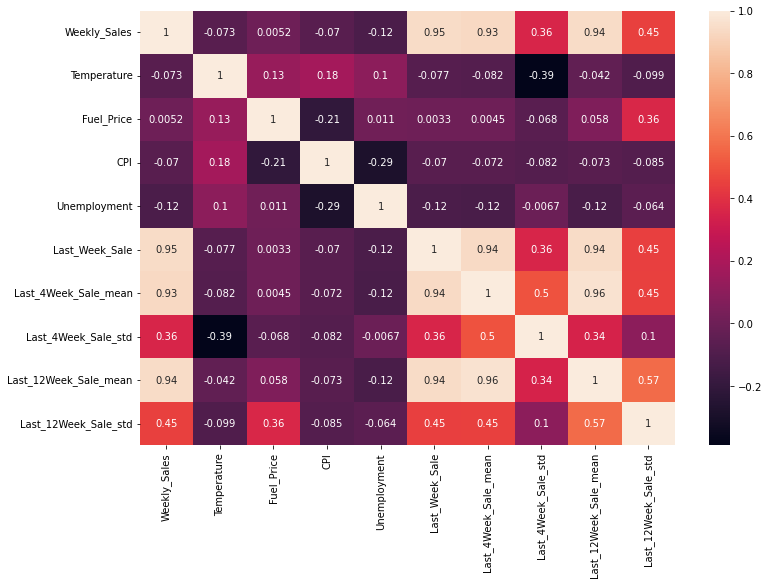

In [75]:
plt.figure(figsize=(12,8))
sns.heatmap(data[selected_columns].corr(method='pearson'), annot=True)
plt.show()

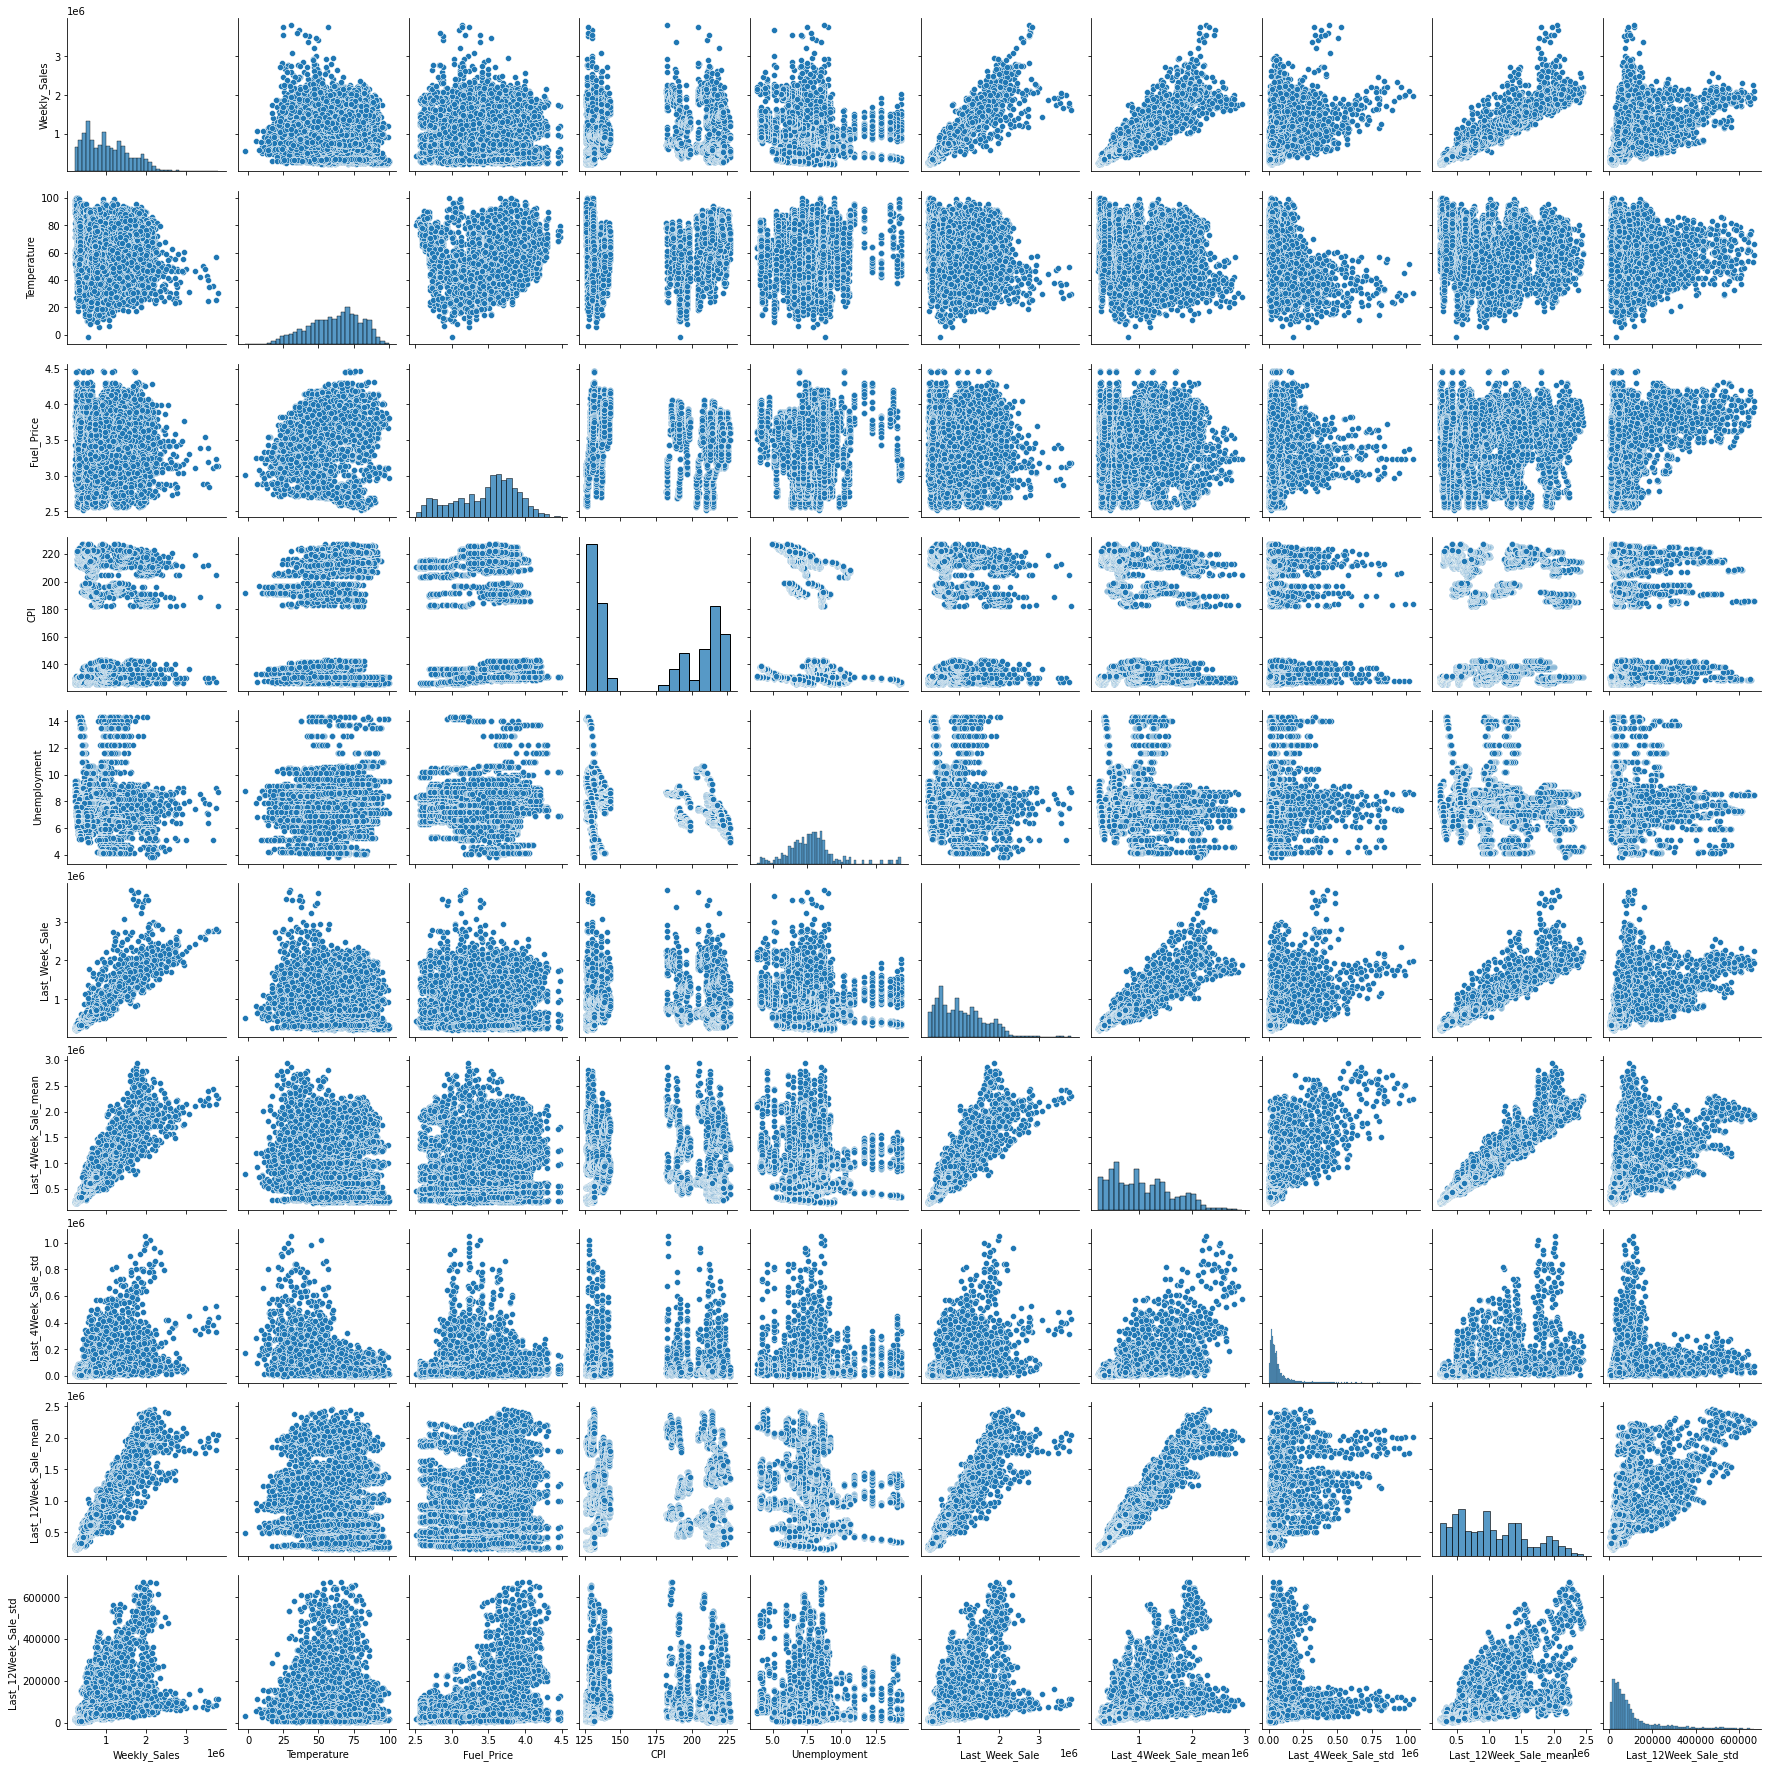

In [76]:
sns.pairplot(data[selected_columns])

In [94]:
data['Year'].unique()

array([2010, 2011, 2012])

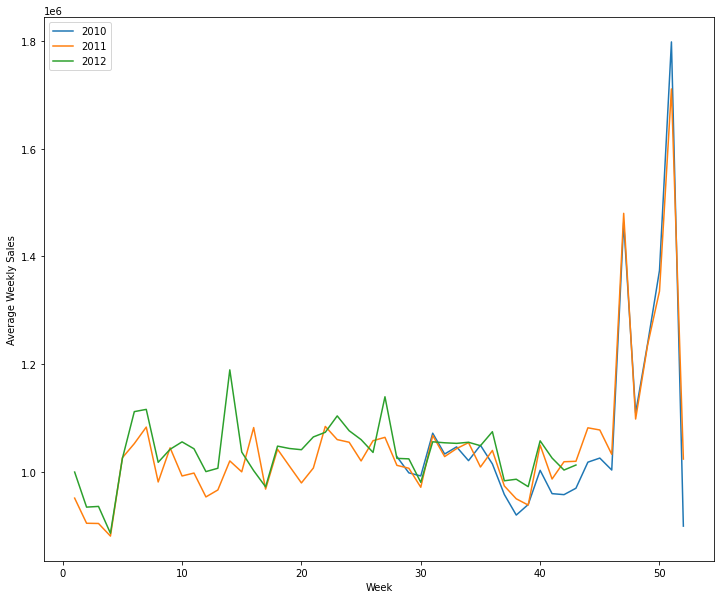

In [93]:
#Time series feature
plt.figure(figsize=(12,10))
years = [2010, 2011, 2012]
for year in years:
    temp = data[data['Year']==year]
    temp = temp[['Week','Weekly_Sales']].groupby('Week').mean().reset_index(level=0)
    plt.plot(temp['Week'],temp['Weekly_Sales'], label=year)
    plt.legend()
    plt.xlabel('Week')
    plt.ylabel('Average Weekly Sales')
plt.show()

In [95]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString,Year,Month,Week,Season,Last_Week_Sale,Last_4Week_Sale_mean,Last_4Week_Sale_std,Last_12Week_Sale_mean,Last_12Week_Sale_std
23,1,2010-07-16,1448938.92,0,83.15,2.623,211.100385,7.787,16-07-2010,2010,7,28,Summer,1546074.18,1.523360e+06,76594.021138,1.514695e+06,95107.965230
24,1,2010-07-23,1385065.20,0,83.36,2.608,211.235144,7.787,23-07-2010,2010,7,29,Summer,1448938.92,1.521020e+06,80362.229620,1.496479e+06,88885.083286
25,1,2010-07-30,1371986.60,0,81.84,2.640,211.369903,7.787,30-07-2010,2010,7,30,Summer,1385065.20,1.490244e+06,49908.159003,1.493312e+06,83759.904242
26,1,2010-08-06,1605491.78,0,87.16,2.627,211.504662,7.787,06-08-2010,2010,8,31,Summer,1371986.60,1.491122e+06,51151.150516,1.483503e+06,75039.274445
27,1,2010-08-13,1508237.76,0,87.00,2.692,211.639421,7.787,13-08-2010,2010,8,32,Summer,1605491.78,1.477536e+06,53982.923313,1.482664e+06,75989.148419


In [96]:
data.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'DateString', 'Year', 'Month',
       'Week', 'Season', 'Last_Week_Sale', 'Last_4Week_Sale_mean',
       'Last_4Week_Sale_std', 'Last_12Week_Sale_mean', 'Last_12Week_Sale_std'],
      dtype='object')

In [113]:
categorical_features = ['Store', 'Holiday_Flag','Week']
numerical_features =['Temperature','CPI', 'Unemployment','Last_Week_Sale', 'Last_4Week_Sale_mean',
       'Last_4Week_Sale_std', 'Last_12Week_Sale_mean', 'Last_12Week_Sale_std']
target=['Weekly_Sales']

In [116]:
X = data[categorical_features + numerical_features]
y = data[target]

In [ ]:
#Handle outliers

<AxesSubplot:xlabel='Weekly_Sales'>

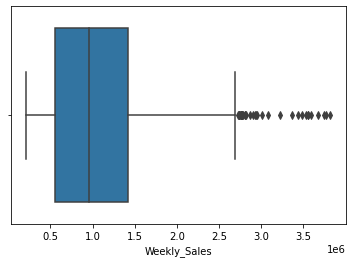

In [101]:
plt.figure()
sns.boxplot(data=data, x='Weekly_Sales')

In [106]:
def filterIQR(feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    return lower_bound, upper_bound

In [107]:
lower_bound, upper_bound = filterIQR('Weekly_Sales')

In [108]:
lower_bound, upper_bound

(-746797.8150000001, 2726949.4050000003)

In [110]:
data_clean = data[data['Weekly_Sales']<=upper_bound]

In [111]:
## Feature transformation

In [114]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [118]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, shuffle=True)

In [119]:
X_train.shape

(3780, 11)

In [120]:
X_test.shape

(1620, 11)

In [121]:
#Preporcess data
preprocessor = ColumnTransformer([
    ('numerical_features', StandardScaler(), numerical_features),
    ('categorical_features', OneHotEncoder(handle_unknown='error', drop='first'), categorical_features)
])

In [122]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numerical_features', StandardScaler(),
                                 ['Temperature', 'CPI', 'Unemployment',
                                  'Last_Week_Sale', 'Last_4Week_Sale_mean',
                                  'Last_4Week_Sale_std',
                                  'Last_12Week_Sale_mean',
                                  'Last_12Week_Sale_std']),
                                ('categorical_features',
                                 OneHotEncoder(drop='first'),
                                 ['Store', 'Holiday_Flag', 'Week'])])

In [123]:
X_train_processed = preprocessor.transform(X_train)

In [129]:
#preprocessor.named_transformers_['categorical_features'].get_feature_names(categorical_features)

In [130]:
#X_train_processed.toarray()

In [131]:
X_test_processed = preprocessor.transform(X_test)

## Modeling

In [136]:
from sklearn.preprocessing import PolynomialFeatures

In [133]:
from sklearn.linear_model import LinearRegression

In [134]:
from sklearn.pipeline import Pipeline 

In [163]:
from sklearn.model_selection import RepeatedKFold, GridSearchCV, cross_val_score

In [160]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [143]:
LR = Pipeline([
    ('polynom', PolynomialFeatures()),
    ('regressor', LinearRegression())
])

In [145]:
#search space
space=dict()
space['polynom__degree']=[1,2,3]

In [146]:
cv = RepeatedKFold(n_splits =5, n_repeats=1, random_state=42)

In [147]:
search = GridSearchCV(LR, space, cv=cv, scoring='neg_root_mean_squared_error')

In [148]:
results = search.fit(X_train_processed, y_train)

In [149]:
results.best_params_

{'polynom__degree': 3}

In [150]:
results.best_score_

-85920.3277339323

In [152]:
best_model=results.best_estimator_

In [154]:
y_test_pred = best_model.predict(X_test_processed)

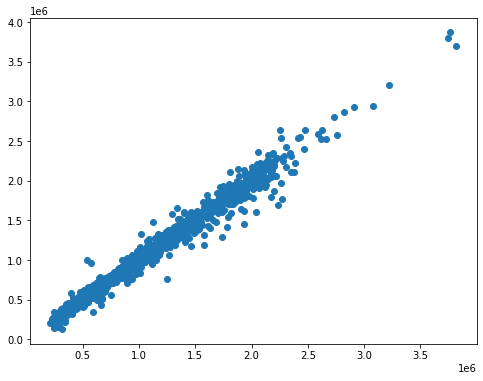

In [156]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_test_pred)
plt.show()

In [162]:
mean_squared_error(y_test, y_test_pred, squared=False)

76630.96731552237

In [166]:
r2_score(y_test, y_test_pred)

0.9828691478443554

In [165]:
cross_val_score(best_model, X_train_processed, y_train, cv =5, scoring='neg_mean_squared_error')

array([-6.51416281e+09, -6.41877550e+09, -8.46155664e+09, -7.92564107e+09,
       -6.32077328e+09])